# Tabular-Only XGBoost — Mixed-All Multimodal Dataset

XGBoost on transaction features only from `mm_*_mixed_all_group_test.csv`.

### Two parts — mirrors notebook 12
**Part A — Raw features** (7 transaction variables)
**Part B — Engineered features** (adds 5 balance-delta/ratio features)

### Three imbalance variants per part — mirrors notebook 12
1. None — no correction
2. scale_pos_weight — XGBoost built-in class weighting
3. SMOTE — oversample minority class

### Feature note
`tab_isFraud` is **excluded** — `final_label` is derived from it (leakage).
`tab_isFlaggedFraud` is **included** — PaySim rule-based flag, not the label.

## 0 · Setup

In [3]:
import sys, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from tabular_xgboost_utils import (
    build_preprocessor, compute_scale_pos_weight,
    build_xgb_pipeline, fit_model,
    evaluate_model, search_thresholds, compute_cost_table,
    evaluate_with_threshold, compute_expected_cost_from_cm,
    save_experiment_outputs,
)

PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_ROOT = PROJECT_ROOT / "notebook" / "results" / "mm_tabular_xgboost"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
print("Results dir:", RESULTS_ROOT)

Results dir: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost


## 1 · Load data

In [4]:
train_df = pd.read_csv(DATA_DIR / "mm_train_mixed_all_group_test.csv")
val_df   = pd.read_csv(DATA_DIR / "mm_val_mixed_all_group_test.csv")
test_df  = pd.read_csv(DATA_DIR / "mm_test_mixed_all_group_test.csv")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 7,182 | Val: 1,508 | Test: 1,474


## 2 · Feature definitions & engineering

In [5]:
from mm_tabular_utils import (
    TARGET_COL, RAW_COLS, FE_COLS,
    NUMERIC_RAW, NUMERIC_FE, CAT_COLS,
    engineer_features, validate_features, print_feature_summary,
    FORBIDDEN_COLS,
)

print_feature_summary()

validate_features(RAW_COLS)
validate_features(FE_COLS)

Raw features  (8): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_type']
FE  features  (13): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed', 'tab_type']

Forbidden (excluded): ['combo_type', 'final_label', 'img_final_label', 'img_image_class', 'img_image_path', 'img_original_label', 'img_source_dataset', 'img_split', 'mm_id', 'split', 'tab_final_label', 'tab_isFraud']
Feature validation passed — 8 features, no leakage.
Feature validation passed — 13 features, no leakage.


## 3 · Imbalance analysis

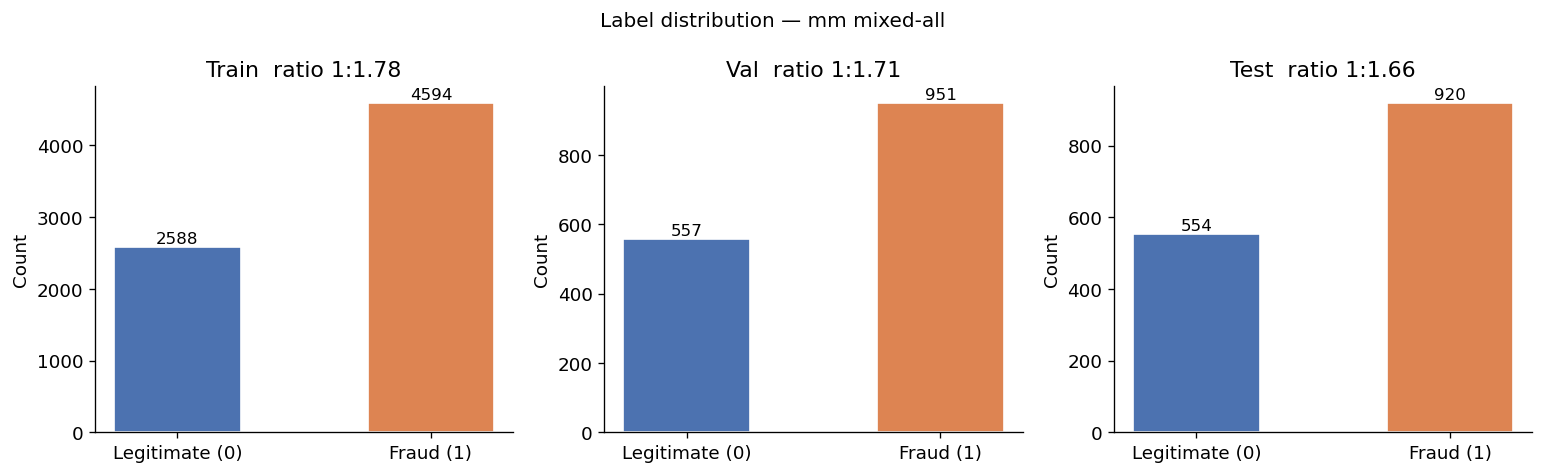

Label imbalance: 2588 legitimate vs 4594 fraud  (ratio 1:1.78)

Imbalance strategies to test:
  1. None         — no correction, raw training
  2. Class weight — balanced class_weight in classifier
  3. SMOTE        — oversample minority class (tabular only, not images)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, df) in zip(axes, [("Train",train_df),("Val",val_df),("Test",test_df)]):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0)/max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}")
    ax.set_ylabel("Count"); ax.spines[["top","right"]].set_visible(False)
fig.suptitle("Label distribution — mm mixed-all", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_ROOT / "label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

n0 = (train_df[TARGET_COL]==0).sum()
n1 = (train_df[TARGET_COL]==1).sum()
print(f"Label imbalance: {n0} legitimate vs {n1} fraud  (ratio 1:{n1/n0:.2f})")
print(f"\nImbalance strategies to test:")
print("  1. None         — no correction, raw training")
print("  2. Class weight — balanced class_weight in classifier")
print("  3. SMOTE        — oversample minority class (tabular only, not images)")

## 4 · Experiment helper

In [7]:
from xml.parsers.expat import model


def run_xgb_experiment(label, results_dir, X_tr, y_tr, X_v, y_v, X_te, y_te,
                       numeric_cols, imbalance_method, spw_val=1.0, smote_strategy=1.0):
    results_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*55}\n{label}\n{'='*55}")

    preprocessor = build_preprocessor(numeric_cols, CAT_COLS)
    model = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method=imbalance_method,
        random_state=RANDOM_STATE,
        scale_pos_weight=spw_val,
        smote_sampling_strategy=smote_strategy,
    )
    model = fit_model(model, X_tr, y_tr, eval_set=(X_v, y_v))

    val_metrics, val_cm = evaluate_model(model, X_v, y_v, f"val_{label}")
    threshold_df        = search_thresholds(model, X_v, y_v)
    cost_df             = compute_cost_table(threshold_df, y_v)      
    best_t              = float(cost_df.iloc[0]["threshold"])         
    print(f"  Cost-optimised threshold: {best_t:.2f}")

    tuned_metrics, tun_cm = evaluate_with_threshold(model, X_te, y_te, best_t)

    save_experiment_outputs(
        results_dir=results_dir, model=model,
        val_metrics=val_metrics, test_metrics=val_metrics,
        val_cm=val_cm, test_cm=val_cm,
        threshold_results=threshold_df, cost_df=cost_df,
        tuned_metrics=tuned_metrics, tuned_cm=tun_cm,
        prefix=label,
    )
    print(f"  Tuned F1:       {tuned_metrics['f1']:.4f}")
    print(f"  Tuned Recall:   {tuned_metrics['recall']:.4f}")
    print(f"  Tuned Precision:{tuned_metrics['precision']:.4f}")
    return {"label":label, "model":model, "val_metrics":val_metrics,
            "tuned_metrics":tuned_metrics, "tuned_cm":tun_cm,
            "best_threshold":best_t}

---
## Part A — Raw features

In [8]:
X_train_raw = train_df[RAW_COLS]; y_train = train_df[TARGET_COL]
X_val_raw   = val_df[RAW_COLS];   y_val   = val_df[TARGET_COL]
X_test_raw  = test_df[RAW_COLS];  y_test  = test_df[TARGET_COL]

spw = compute_scale_pos_weight(y_train)
print(f"scale_pos_weight = {spw:.3f}")

ra_none = run_xgb_experiment("A_none",   RESULTS_ROOT/"A_none",   X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test, NUMERIC_RAW, "none")
ra_spw  = run_xgb_experiment("A_weight", RESULTS_ROOT/"A_weight", X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test, NUMERIC_RAW, "scale_pos_weight", spw_val=spw)
ra_sm   = run_xgb_experiment("A_smote",  RESULTS_ROOT/"A_smote",  X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test, NUMERIC_RAW, "smote", smote_strategy=1.0)

scale_pos_weight = 0.563

A_none
  Early stopping: used 107 / 300 trees.

=== VAL_A_NONE ===
  accuracy: 0.713528
  precision: 0.843709
  recall: 0.669821
  f1: 0.746776
  roc_auc: 0.791150
  pr_auc: 0.897386

Confusion matrix:
 [[439 118]
 [314 637]]

Classification report:
              precision    recall  f1-score   support

           0     0.5830    0.7882    0.6702       557
           1     0.8437    0.6698    0.7468       951

    accuracy                         0.7135      1508
   macro avg     0.7134    0.7290    0.7085      1508
weighted avg     0.7474    0.7135    0.7185      1508

  Cost-optimised threshold: 0.10

Tuned threshold : 0.1
  Precision     : 0.624152
  Recall        : 1.000000
  F1            : 0.768588

Confusion matrix:
 [[  0 554]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       554
           1     0.6242    1.0000    0.7686       920

    accuracy                 

---
## Part B — Engineered features

In [9]:
train_fe = engineer_features(train_df)
val_fe   = engineer_features(val_df)
test_fe  = engineer_features(test_df)

X_train_fe = train_fe[FE_COLS]; X_val_fe = val_fe[FE_COLS]; X_test_fe = test_fe[FE_COLS]

spw_fe = compute_scale_pos_weight(y_train)

rb_none = run_xgb_experiment("B_none",   RESULTS_ROOT/"B_none",   X_train_fe, y_train, X_val_fe, y_val, X_test_fe, y_test, NUMERIC_FE, "none")
rb_spw  = run_xgb_experiment("B_weight", RESULTS_ROOT/"B_weight", X_train_fe, y_train, X_val_fe, y_val, X_test_fe, y_test, NUMERIC_FE, "scale_pos_weight", spw_val=spw_fe)
rb_sm   = run_xgb_experiment("B_smote",  RESULTS_ROOT/"B_smote",  X_train_fe, y_train, X_val_fe, y_val, X_test_fe, y_test, NUMERIC_FE, "smote", smote_strategy=1.0)


B_none
  Early stopping: used 86 / 300 trees.

=== VAL_B_NONE ===
  accuracy: 0.722812
  precision: 0.873773
  recall: 0.655100
  f1: 0.748798
  roc_auc: 0.786112
  pr_auc: 0.897102

Confusion matrix:
 [[467  90]
 [328 623]]

Classification report:
              precision    recall  f1-score   support

           0     0.5874    0.8384    0.6908       557
           1     0.8738    0.6551    0.7488       951

    accuracy                         0.7228      1508
   macro avg     0.7306    0.7468    0.7198      1508
weighted avg     0.7680    0.7228    0.7274      1508

  Cost-optimised threshold: 0.10

Tuned threshold : 0.1
  Precision     : 0.624152
  Recall        : 1.000000
  F1            : 0.768588

Confusion matrix:
 [[  0 554]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       554
           1     0.6242    1.0000    0.7686       920

    accuracy                         0.6242      1474
 

---
## Comparison — all six variants

In [10]:
all_results = [ra_none, ra_spw, ra_sm, rb_none, rb_spw, rb_sm]

comparison_df = pd.DataFrame([
    {"experiment":  r["label"],
     "features":    "Raw" if r["label"].startswith("A") else "Engineered",
     "imbalance":   r["label"].split("_")[1],
     "val_f1":      r["val_metrics"]["f1"],
     "val_roc_auc": r["val_metrics"]["roc_auc"],
     "val_pr_auc":  r["val_metrics"].get("pr_auc", float("nan")),
     "best_threshold": r["best_threshold"],
     "tuned_f1":    r["tuned_metrics"]["f1"],
     "tuned_recall":r["tuned_metrics"]["recall"],
     "tuned_precision":r["tuned_metrics"]["precision"],
     "tuned_cost":  compute_expected_cost_from_cm(r["tuned_cm"])["expected_cost"]}
    for r in all_results
])
comparison_df.to_csv(RESULTS_ROOT / "comparison.csv", index=False)
display(comparison_df.round(4))

,experiment,features,imbalance,val_f1,val_roc_auc,val_pr_auc,best_threshold,tuned_f1,tuned_recall,tuned_precision,tuned_cost
0,A_none,Raw,none,0.7468,0.7911,0.8974,0.10,0.7686,1.0,0.6242,277000
1,A_weight,Raw,weight,0.7470,0.7858,0.8956,0.10,0.7686,1.0,0.6242,277000
2,A_smote,Raw,smote,0.7442,0.7913,0.8980,0.10,0.7686,1.0,0.6242,277000
3,B_none,Engineered,none,0.7488,0.7861,0.8971,0.10,0.7686,1.0,0.6242,277000
4,B_weight,Engineered,weight,0.7498,0.7845,0.8965,0.10,0.7686,1.0,0.6242,277000
5,B_smote,Engineered,smote,0.7489,0.7897,0.8982,0.15,0.7689,1.0,0.6246,276500


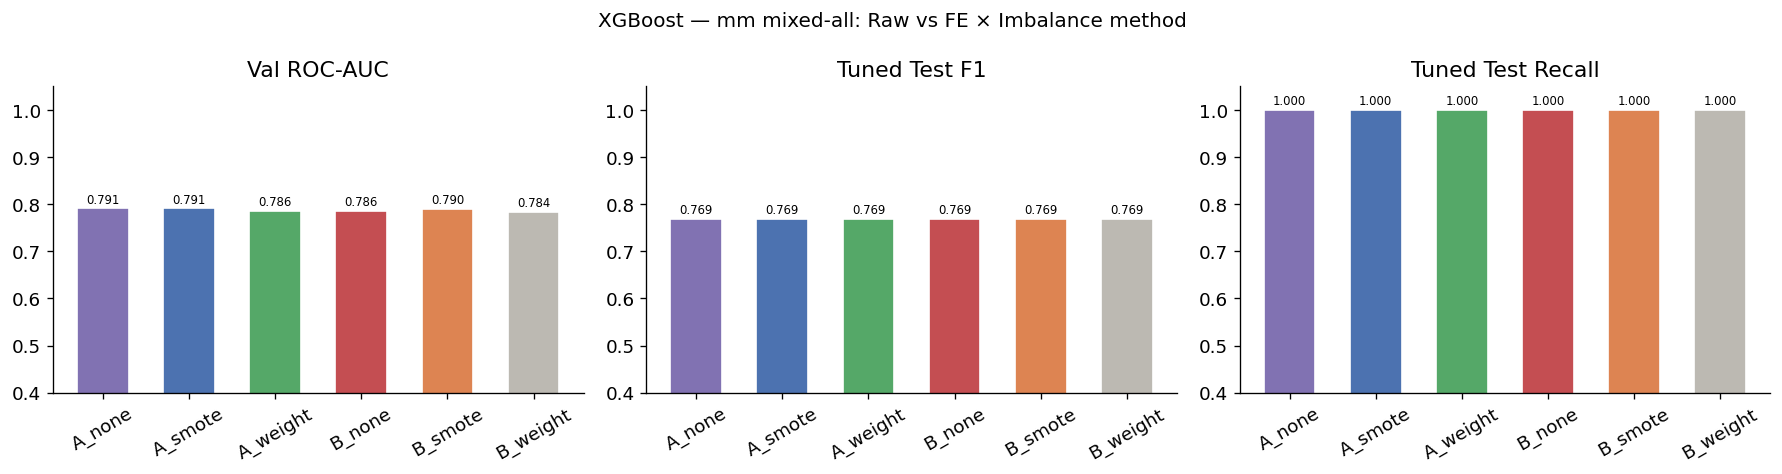

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bar_colours = ["#8172B2","#4C72B0","#55A868","#C44E52","#DD8452","#BCB9B2"]

for ax, metric, title in zip(axes,
    ["val_roc_auc","tuned_f1","tuned_recall"],
    ["Val ROC-AUC","Tuned Test F1","Tuned Test Recall"]):
    sorted_df = comparison_df.sort_values("experiment")
    bars = ax.bar(sorted_df["experiment"], sorted_df[metric],
                  color=bar_colours[:len(sorted_df)], edgecolor="white", width=0.6)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(title); ax.set_ylim(0.4, 1.05)
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("XGBoost — mm mixed-all: Raw vs FE × Imbalance method", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_ROOT / "comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature importance (best model)

In [12]:
best_r = max(all_results, key=lambda r: r["tuned_metrics"]["f1"])
feat_cols = RAW_COLS if best_r["label"].startswith("A") else FE_COLS
print(f"Best variant: {best_r['label']}")

try:
    clf = list(best_r["model"].named_steps.values())[-1]
    feat_df = pd.DataFrame({
        "feature":    feat_cols,
        "importance": clf.feature_importances_,
    }).sort_values("importance", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(feat_df["feature"], feat_df["importance"],
            color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Importance")
    ax.set_title(f"Feature importance — {best_r['label']}")
    ax.spines[["top","right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(RESULTS_ROOT / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Could not plot: {e}")

Best variant: B_smote
Could not plot: All arrays must be of the same length


In [13]:
for variant in ["A_none", "A_weight", "A_smote"]:
    thr_path = RESULTS_ROOT / variant / f"{variant}_threshold_results.csv"
    if thr_path.exists():
        df = pd.read_csv(thr_path)
        print(f"\n{variant}:")
        print(df[["threshold","f1","recall","precision"]].to_string())


A_none:
    threshold        f1    recall  precision
0        0.10  0.773485  1.000000   0.630637
1        0.15  0.772986  0.998948   0.630392
2        0.20  0.772986  0.998948   0.630392
3        0.25  0.772116  0.995794   0.630493
4        0.30  0.772895  0.989485   0.634097
5        0.35  0.773946  0.955836   0.650215
6        0.40  0.766931  0.863302   0.689916
7        0.45  0.753041  0.748686   0.757447
8        0.50  0.746776  0.669821   0.843709
9        0.55  0.745050  0.633018   0.905263
10       0.60  0.744010  0.620400   0.929134
11       0.65  0.745524  0.613039   0.951060
12       0.70  0.748220  0.607781   0.973064
13       0.75  0.736911  0.592008   0.975737
14       0.80  0.722074  0.570978   0.981917
15       0.85  0.707630  0.550999   0.988679
16       0.90  0.688660  0.526814   0.994048
17       0.95  0.666200  0.500526   0.995816

A_weight:
    threshold        f1    recall  precision
0        0.10  0.773485  1.000000   0.630637
1        0.15  0.772487  0.997897  

## Final summary

In [14]:
best = comparison_df.sort_values("tuned_f1", ascending=False).iloc[0]
print(f"Best XGBoost variant: {best['experiment']}")
print(f"  Features  : {best['features']}")
print(f"  Imbalance : {best['imbalance']}")
print(f"  Threshold : {best['best_threshold']:.2f}")
print(f"  F1        : {best['tuned_f1']:.4f}")
print(f"  Recall    : {best['tuned_recall']:.4f}")
print(f"  ROC-AUC   : {best['val_roc_auc']:.4f}")
print(f"\nAll results saved to: {RESULTS_ROOT}")

Best XGBoost variant: B_smote
  Features  : Engineered
  Imbalance : smote
  Threshold : 0.15
  F1        : 0.7689
  Recall    : 1.0000
  ROC-AUC   : 0.7897

All results saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost
